In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix
from sktime.forecasting.conditional_invertible_neural_network import default_sine

In [53]:
def preprocess_design_matrix(design_matrix):

    design_matrix = design_matrix[design_matrix['sofa_liver_baseline'] == 0.0]

    design_matrix = design_matrix[design_matrix['sofa_liver_day1'] == 1.0]

    design_matrix['max_liver_diff'] = np.max(
        design_matrix[
            [
                #'sofa_liver_day1',
                'sofa_liver_day2', 
                'sofa_liver_day3'
            ]
        ], 
        axis=1
    )

    design_matrix['group'] = np.where(
        design_matrix['max_liver_diff'] > 0, 2, 1
    )

    # design_matrix = design_matrix[
    #     (design_matrix['bili_highest_72h'] < 20) |
    #     (design_matrix['bili_highest_72h'] > 32)
    # ].copy()

    # design_matrix['group'] = np.where(
    #     design_matrix['bili_highest_72h'] > 32, 2, 1
    # )

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [54]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix     

# Model Training

In [55]:
ms_data = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)

In [56]:
design_matrix_otrain = pd.read_csv(
    "../0_data/design_matrix_train.tsv",
    sep='\t'
)

In [57]:
for col in design_matrix_otrain.columns:

    if "bili" in col:

        print(col)

bili_emergency_department


In [58]:
design_matrix_train = preprocess_design_matrix(design_matrix_otrain.copy())

<Axes: xlabel='max_liver_diff', ylabel='Count'>

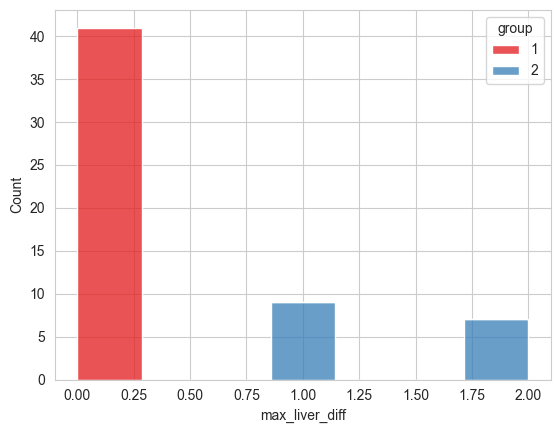

In [59]:
sns.histplot(
    design_matrix_train,
    x="max_liver_diff",
    hue="group",
    palette="Set1",
    multiple="stack"
)

In [60]:
design_matrix_train['group'].value_counts()

group
1    42
2    16
Name: count, dtype: int64

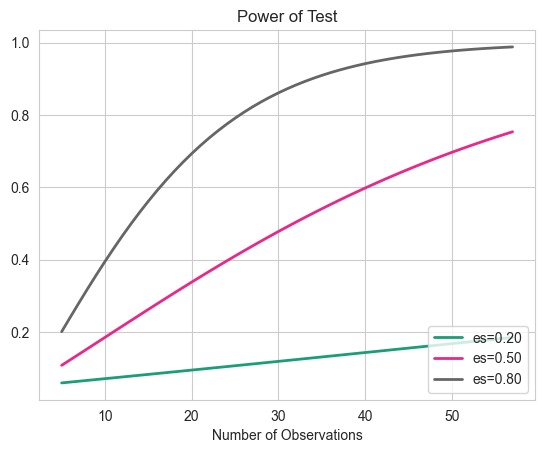

In [61]:
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

# parameters for power analysis
effect_sizes = np.array([0.2, 0.5, 0.8])
sample_sizes = np.array(range(5, design_matrix_train.shape[0]))


analysis = TTestIndPower()

analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes)
plt.show()

In [62]:
quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [63]:
quant_matrix_train = quant_matrix_train.compare(
    method="linregress",
    comparisons=(2,1),
    min_samples_per_group=2,
    level="protein",
    multiple_testing_correction_method="fdr_tsbh"
)

In [64]:
quant_matrix_train.write("de_results/liver_de_proteins.tsv")

In [65]:
quant_matrix_de = quant_matrix_train.to_df()

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

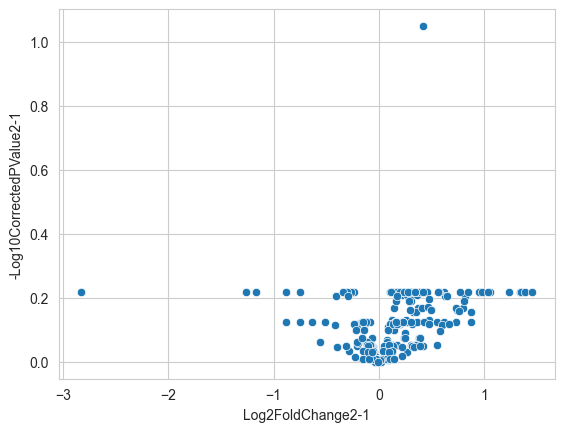

In [66]:
sns.scatterplot(
    data=quant_matrix_de,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1"
)

In [67]:
qm_filtered = (
    
    QuantMatrix(
        quantification_file=quant_matrix_de,
        design_matrix_file=design_matrix_train
    )
    
)

In [68]:
training_data, y = qm_filtered.to_ml(feature_column="ProteinLabel")

In [69]:
protein_columns = training_data.columns.to_list()

In [70]:
len(protein_columns)

287

In [71]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer

X = training_data.copy()

protein_scaler = StandardScaler()

X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

X = X.copy()

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier


protein_clf = LogisticRegression(
    random_state=42,
    #penalty="l1",
    class_weight="balanced",
    #C=0.1,
    #solver="liblinear",
    max_iter=1000
)

# protein_clf = BaggingClassifier(
#     estimator=protein_clf,
#     random_state=42
# )

In [73]:
from cleanlab.filter import find_label_issues
from sklearn.model_selection import cross_val_predict

pred_probs = cross_val_predict(protein_clf, X, y.values.ravel(), cv=3, method="predict_proba")

label_issues = find_label_issues(
    labels=y.values.ravel(),
    pred_probs=pred_probs,
    return_indices_ranked_by='self_confidence'  # Ranks by likelihood of being mislabeled
)

ModuleNotFoundError: No module named 'cleanlab'

In [74]:
mask = np.ones(len(y.values.ravel()), dtype=bool)

mask[label_issues] = False

NameError: name 'label_issues' is not defined

In [75]:
X = X.iloc[mask, :].copy()
y = y.iloc[mask, :].copy()

In [76]:
y['label'].value_counts()

label
0    42
1    16
Name: count, dtype: int64

In [77]:
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight


class_weight = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y.values.ravel()),
    y=y.values.ravel()
)

class_weight = dict(zip(np.unique(y.values.ravel()), class_weight))

class_weight

{0: 0.6904761904761905, 1: 1.8125}

In [78]:
len(protein_columns)

287

In [79]:
from mrmr import mrmr_classif
selected_proteins = mrmr_classif(X=X[protein_columns], y=y.values.ravel(), K=50)

100%|██████████| 50/50 [00:00<00:00, 61.55it/s]


In [80]:
selected_proteins

['MA1A1_HUMAN',
 'TRY3_HUMAN',
 'RNAS4_HUMAN',
 'AMPN_HUMAN',
 'PXDC2_HUMAN',
 'COL10_HUMAN',
 'CPN2_HUMAN',
 'PCOC1_HUMAN',
 'HPTR_HUMAN',
 'ALDOB_HUMAN',
 'TRY1_HUMAN',
 'THIO_HUMAN',
 'FCN2_HUMAN',
 'FETUB_HUMAN',
 'C163A_HUMAN',
 'CMGA_HUMAN',
 'VINC_HUMAN',
 'PON3_HUMAN',
 'ALDOA_HUMAN',
 'CETP_HUMAN',
 'IC1_HUMAN',
 'HGFA_HUMAN',
 'PEBP4_HUMAN',
 'TFR1_HUMAN',
 'CALM1_HUMAN',
 'VSIG4_HUMAN',
 'C1R_HUMAN',
 'HPT_HUMAN',
 'CO5_HUMAN',
 'H4_HUMAN',
 'NID1_HUMAN',
 'FCN3_HUMAN',
 'CFAD_HUMAN',
 'CBPN_HUMAN',
 'APOL1_HUMAN',
 'CAP1_HUMAN',
 'VTNC_HUMAN',
 'K2C1_HUMAN',
 'ENOA_HUMAN',
 'CRP_HUMAN',
 'MMP2_HUMAN',
 'VWF_HUMAN',
 'THRB_HUMAN',
 'FETUA_HUMAN',
 'FA5_HUMAN',
 'PLTP_HUMAN',
 'CATD_HUMAN',
 'G3P_HUMAN',
 'FA10_HUMAN',
 'MBL2_HUMAN']

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier


protein_clf = LogisticRegression(
    class_weight=class_weight,
    random_state=42
)

In [82]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3)
eval_result = cross_validate(
    protein_clf, X[selected_proteins], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean()

(0.35555555555555557,
 0.5238095238095238,
 0.7412280701754387,
 0.6182539682539682)

In [83]:
from dpks.interpretation import BootstrapInterpreter

protein_interpreter = BootstrapInterpreter(
    n_iterations=100,
    feature_names=selected_proteins,
    downsample_background=True,
    shuffle_iterations=100
)

In [33]:
protein_interpreter.fit(X[selected_proteins].values, y.values.ravel(), protein_clf)

In [34]:
protein_importances = protein_interpreter.results_.sort_values("mean_importance", ascending=False)

In [35]:
protein_importances.head(20)

,feature,iteration_0_importance,iteration_0_rank,iteration_1_importance,iteration_1_rank,iteration_2_importance,iteration_2_rank,iteration_3_importance,iteration_3_rank,iteration_4_importance,...,iteration_98_importance,iteration_98_rank,iteration_99_importance,iteration_99_rank,mean_importance,median_importance,stdev_importance,mean_rank,median_rank,stdev_rank
27,PZP_HUMAN,0.322897,13.0,0.818789,2.0,0.393487,16.0,0.405388,11.0,0.571095,...,0.815486,2.0,1.000000,1.0,0.652672,0.658293,0.264769,9.47,7.0,9.425363
12,PIGR_HUMAN,0.250514,20.0,0.321428,16.0,0.630324,6.0,0.759999,2.0,0.773694,...,0.013314,50.0,0.347083,14.0,0.548174,0.524142,0.283076,13.64,11.0,12.382392
38,VCAM1_HUMAN,0.294860,15.0,0.391419,13.0,1.000000,1.0,0.327464,16.0,0.510266,...,0.348606,13.0,0.436302,8.0,0.522742,0.500867,0.278312,14.62,11.0,11.605276
6,AMPN_HUMAN,0.352583,8.0,0.731203,4.0,0.276898,31.0,0.331253,14.0,0.574520,...,0.411508,10.0,0.448639,7.0,0.504831,0.479233,0.196608,12.96,12.0,7.801735
18,C4BPB_HUMAN,0.449038,4.0,0.551869,6.0,0.786666,4.0,0.476197,8.0,0.451311,...,0.498978,8.0,0.380524,12.0,0.469949,0.451087,0.239093,15.96,12.5,12.090500
3,ALDOB_HUMAN,0.333793,11.0,0.003092,50.0,0.595866,9.0,0.434699,9.0,0.922431,...,0.728600,3.0,0.235202,25.0,0.467425,0.438714,0.255396,16.43,14.0,12.000215
20,CRIS3_HUMAN,0.239776,21.0,0.129386,28.0,0.337579,24.0,0.263489,23.0,0.605645,...,1.000000,1.0,0.380448,13.0,0.465596,0.464804,0.219967,15.71,13.0,10.642297
26,FIBG_HUMAN,0.291794,16.0,0.562450,5.0,0.236665,35.0,0.256533,24.0,0.069719,...,0.327028,15.0,0.227918,26.0,0.446745,0.432830,0.204752,16.43,14.0,10.772444
23,LKHA4_HUMAN,0.344960,9.0,0.203511,22.0,0.230167,37.0,0.652754,6.0,0.910022,...,0.098999,42.0,0.983679,2.0,0.429920,0.412738,0.281919,19.84,16.0,14.948883
0,BGH3_HUMAN,0.331623,12.0,0.743399,3.0,0.998795,2.0,0.207473,31.0,0.347249,...,0.132755,36.0,0.484290,6.0,0.428511,0.413762,0.267943,19.72,17.5,14.572757


In [36]:
selected_proteins = protein_importances.head(10)['feature'].to_list()

In [37]:
from dpks.interpretation import Classifier


protein_clf = Classifier(protein_clf)

In [38]:
selected_features = selected_proteins[:10]

In [39]:
for feature in selected_features:

    print(feature)

PZP_HUMAN
PIGR_HUMAN
VCAM1_HUMAN
AMPN_HUMAN
C4BPB_HUMAN
ALDOB_HUMAN
CRIS3_HUMAN
FIBG_HUMAN
LKHA4_HUMAN
BGH3_HUMAN


In [40]:
protein_clf = LogisticRegression(
    class_weight=class_weight,
    random_state=42
)

In [41]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3, shuffle=True, random_state=42)
eval_result = cross_validate(
    protein_clf, X[selected_features], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean()

(0.8333333333333334, 0.3870931537598204, 0.8830144667009074, 0.860322149006539)

In [42]:
cv = StratifiedKFold(3, shuffle=True, random_state=42)
eval_result = cross_validate(
    protein_clf, X[protein_columns], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean()

(0.5714285714285715,
 0.6583139083139083,
 0.9434493237459339,
 0.7734317236703058)

In [43]:
from dpks.interpretation import BootstrapInterpreter

final_protein_interpreter = BootstrapInterpreter(
    n_iterations=100,
    feature_names=selected_features,
    downsample_background=True,
    shuffle_iterations=100
)

In [44]:
final_protein_interpreter.fit(X[selected_features].values, y.values.ravel(), protein_clf)

In [45]:
final_protein_importances = final_protein_interpreter.results_.sort_values("mean_importance", ascending=False)

In [46]:
final_protein_importances

,feature,iteration_0_importance,iteration_0_rank,iteration_1_importance,iteration_1_rank,iteration_2_importance,iteration_2_rank,iteration_3_importance,iteration_3_rank,iteration_4_importance,...,iteration_98_importance,iteration_98_rank,iteration_99_importance,iteration_99_rank,mean_importance,median_importance,stdev_importance,mean_rank,median_rank,stdev_rank
4,C4BPB_HUMAN,1.000000,1.0,0.813700,2.0,1.000000,1.0,0.690415,4.0,1.000000,...,1.000000,1.0,0.785828,4.0,0.901717,1.000000,0.145523,2.11,1.0,1.601104
7,FIBG_HUMAN,0.647631,2.0,1.000000,1.0,0.770969,3.0,0.845508,2.0,0.725913,...,0.641196,5.0,0.688701,5.0,0.749905,0.742697,0.176878,3.25,3.0,1.725478
0,PZP_HUMAN,0.161304,10.0,0.591991,3.0,0.333397,8.0,0.676351,5.0,0.417484,...,0.791423,4.0,1.000000,1.0,0.598961,0.586001,0.235388,4.95,5.0,2.384186
5,ALDOB_HUMAN,0.598836,4.0,0.354668,6.0,0.715959,4.0,0.526062,7.0,0.802268,...,0.957932,2.0,0.675992,6.0,0.553751,0.531220,0.209960,5.35,5.0,2.362908
1,PIGR_HUMAN,0.362473,7.0,0.208979,7.0,0.610985,6.0,1.000000,1.0,0.711812,...,0.422155,7.0,0.375549,8.0,0.549995,0.554918,0.220546,5.20,5.0,2.399495
9,BGH3_HUMAN,0.619382,3.0,0.511968,4.0,0.814474,2.0,0.581348,6.0,0.456622,...,0.594585,6.0,0.795725,3.0,0.542911,0.534133,0.253635,5.43,6.0,2.671416
8,LKHA4_HUMAN,0.418521,6.0,0.109608,9.0,0.108681,10.0,0.700666,3.0,0.728681,...,0.351961,8.0,0.853626,2.0,0.451507,0.430383,0.243520,6.38,7.0,2.635346
3,AMPN_HUMAN,0.591522,5.0,0.511033,5.0,0.248961,9.0,0.258944,9.0,0.356919,...,0.298908,9.0,0.422448,7.0,0.431668,0.409601,0.197692,6.86,7.0,2.278667
6,CRIS3_HUMAN,0.252227,9.0,0.112921,8.0,0.640334,5.0,0.260029,8.0,0.445827,...,0.846958,3.0,0.235159,9.0,0.400114,0.380687,0.246382,6.90,8.0,2.615030
2,VCAM1_HUMAN,0.315215,8.0,0.038587,10.0,0.334953,7.0,0.029281,10.0,0.060214,...,0.173490,10.0,0.077752,10.0,0.247092,0.204266,0.201915,8.57,9.0,1.832672


In [47]:
final_protein_importances.to_csv(
    "feature_importances/liver_protein_importances.tsv",
    sep="\t",
    index=False
)

# Model Testing

In [48]:
ms_data_test = pd.read_csv(
    "../0_data/proteins_test_filtered.tsv"
    , sep="\t"
)
design_matrix_test = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)

In [49]:
design_matrix_test = preprocess_design_matrix(design_matrix_test)

quant_matrix_test = preprocess_data(ms_data_test, design_matrix=design_matrix_test)

In [50]:
quant_matrix_test_df = quant_matrix_test.to_df()
#quant_matrix_test_df = quant_matrix_test_df[quant_matrix_test_df['ProteinLabel'].isin(selected_features)]

In [51]:
qm_filtered_test = (
    
    QuantMatrix(
        quantification_file=quant_matrix_test_df,
        design_matrix_file=design_matrix_test
    )
    
)

In [52]:
testing_data, y_test = qm_filtered_test.to_ml(feature_column="ProteinLabel")

In [53]:
X_test = testing_data.copy()

X_test[protein_scaler.feature_names_in_] = protein_scaler.transform(X_test[protein_scaler.feature_names_in_])

X_test = X_test.copy()

In [54]:
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)
svc = SVC(random_state=42)
knn = KNeighborsClassifier()
naive_bayes = GaussianNB()
mlp = MLPClassifier(random_state=42)


lr_clf = LogisticRegression(
    class_weight=class_weight,
    random_state=42
)

# lr_clf = BaggingClassifier(
#     estimator=lr_clf,
#     random_state=42
# )

xgb_clf = XGBClassifier(
    max_depth=5,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    learning_rate=0.01,
    n_estimators=1000,
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    n_jobs=1
)


In [55]:
lr_clf.fit(X[selected_features], y.values.ravel(), )
xgb_clf.fit(X[selected_features], y.values.ravel(), )
decision_tree.fit(X[selected_features], y.values.ravel(), ) 
random_forest.fit(X[selected_features], y.values.ravel(), )
svc.fit(X[selected_features], y.values.ravel(), )
knn.fit(X[selected_features], y.values.ravel()) 
naive_bayes.fit(X[selected_features], y.values.ravel(), ) 
mlp.fit(X[selected_features], y.values.ravel())

MLPClassifier(random_state=42)

In [56]:
from sklearn.metrics import f1_score

lr_predictions = lr_clf.predict(X_test[selected_features])
lr_ba = f1_score(y_test.values.ravel(), lr_predictions)

xgb_predictions = xgb_clf.predict(X_test[selected_features])
xgb_ba = f1_score(y_test.values.ravel(), xgb_predictions)

decision_tree_predictions = decision_tree.predict(X_test[selected_features])
decision_tree_ba = f1_score(y_test.values.ravel(), decision_tree_predictions)

rf_predictions = random_forest.predict(X_test[selected_features])
rf_ba = f1_score(y_test.values.ravel(), rf_predictions)

svc_predictions = svc.predict(X_test[selected_features])
svc_ba = f1_score(y_test.values.ravel(), svc_predictions)

knn_predictions = knn.predict(X_test[selected_features])
knn_ba = f1_score(y_test.values.ravel(), knn_predictions)

nb_predictions = naive_bayes.predict(X_test[selected_features])
nb_ba = f1_score(y_test.values.ravel(), nb_predictions)

mlp_predictions = mlp.predict(X_test[selected_features])
mlp_ba = f1_score(y_test.values.ravel(), mlp_predictions)

In [57]:
lr_ba, xgb_ba, decision_tree_ba, rf_ba, svc_ba, knn_ba, nb_ba, mlp_ba

(0.36619718309859156,
 0.336,
 0.27710843373493976,
 0.31666666666666665,
 0.21818181818181817,
 0.22018348623853212,
 0.4175824175824176,
 0.35384615384615387)

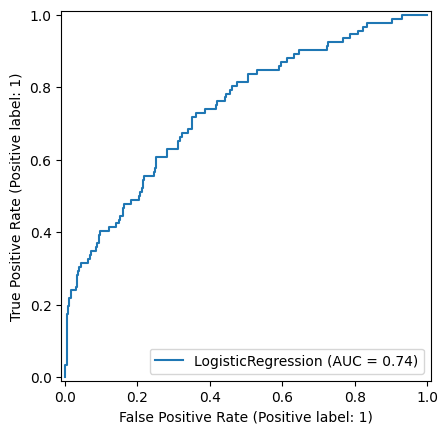

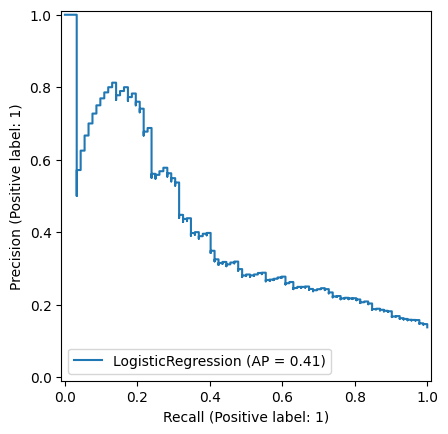

In [58]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

RocCurveDisplay.from_estimator(
    lr_clf, X_test[selected_features], y_test.values.ravel()
)


PrecisionRecallDisplay.from_estimator(
    lr_clf, X_test[selected_features], y_test.values.ravel()
)





In [59]:
from sklearn.metrics import roc_curve

y_probs = lr_clf.predict_proba(X_test[selected_features])[:, 1]

# Compute ROC curve metrics
fpr, tpr, thresholds = roc_curve( y_test.values.ravel(), y_probs)

# Create a DataFrame to store the metrics
roc_df = pd.DataFrame({
    'False Positive Rate': fpr,
    'True Positive Rate': tpr,
    'Threshold': thresholds
})


In [60]:
roc_df.to_csv(
    "roc/liver.tsv",
    sep="\t"
)

# Probability Prediction

In [61]:
design_matrix_test = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)

design_matrix_test['sample'] = design_matrix_test['injection']
design_matrix_test['group'] = 1

quant_matrix_predict = QuantMatrix(
    quantification_file=ms_data_test,
    design_matrix_file=design_matrix_test,
    annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
).impute(method="uniform_percentile", percentile=0.01)

predict_data, y_test_alll = quant_matrix_predict.to_ml(feature_column="ProteinLabel")

In [62]:
predict_data = predict_data[protein_columns].copy()

In [63]:
predict_data[protein_columns] = protein_scaler.transform(predict_data[protein_columns])

In [64]:
predict_data['liver_probability'] = lr_clf.predict_proba(predict_data[selected_features])[:, 1]

In [65]:
design_matrix_test = design_matrix_test.set_index("injection").join(
    predict_data['liver_probability']
).reset_index()

In [66]:
predict_data[['liver_probability']].to_csv(
    "predictions_test/liver.tsv",
    sep="\t"
)

<Axes: xlabel='liver_probability', ylabel='Count'>

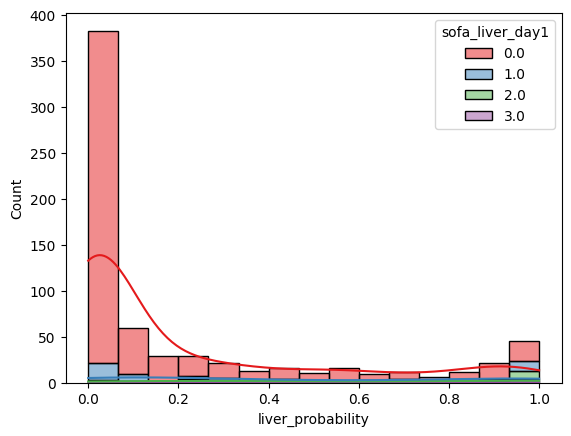

In [67]:
sns.histplot(
    data=design_matrix_test,
    x="liver_probability",
    hue="sofa_liver_day1",
    palette="Set1", 
    kde=True,
    multiple="stack"
)

In [68]:
ms_data_val = pd.read_csv(
    "../0_data/proteins_val_filtered.tsv"
    , sep="\t"
)

design_matrix_val = pd.read_csv(
    "../0_data/design_matrix_validation.tsv",
    sep='\t'
)

design_matrix_val['sample'] = design_matrix_val['injection']
design_matrix_val['group'] = 1

quant_matrix_val = QuantMatrix(
    quantification_file=ms_data_val,
    design_matrix_file=design_matrix_val,
    annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
)

val_data, y_val = quant_matrix_val.to_ml(feature_column="ProteinLabel")

In [69]:
val_data = val_data[protein_columns].copy()

In [70]:
val_data[protein_columns] = protein_scaler.transform(val_data[protein_columns])

In [71]:
val_data['liver_probability'] = lr_clf.predict_proba(val_data[selected_features])[:, 1]

In [72]:
design_matrix_val = design_matrix_val.set_index("injection").join(
    val_data['liver_probability']
).reset_index()

In [73]:
val_data[['liver_probability']].to_csv(
    "predictions_val/liver.tsv",
    sep="\t"
)

<Axes: xlabel='liver_probability', ylabel='Count'>

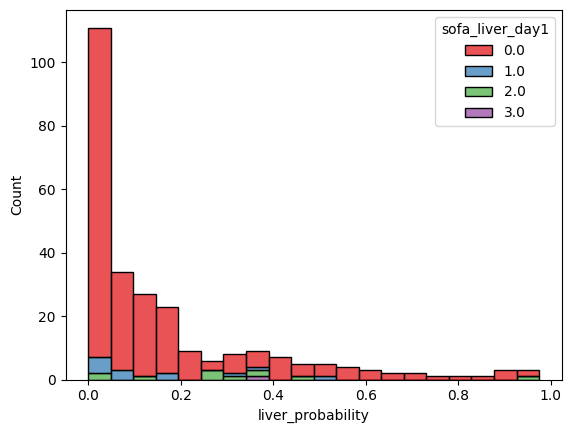

In [74]:
sns.histplot(
    data=design_matrix_val,
    x="liver_probability",
    hue="sofa_liver_day1",
    palette="Set1", 
    #kde=True,
    multiple="stack", 
    bins=20
)

In [75]:
ms_data_hero = pd.read_csv(
    "../0_data/proteins_hero_filtered.tsv"
    , sep="\t"
)

design_matrix_hero = pd.read_csv(
    "../0_data/design_matrix_hero.tsv",
    sep='\t'
)

design_matrix_hero['sample'] = design_matrix_hero['injection']
design_matrix_hero['group'] = 1

quant_matrix_hero = QuantMatrix(
    quantification_file=ms_data_hero,
    design_matrix_file=design_matrix_hero,
    annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
)

hero_data, y_hero = quant_matrix_hero.to_ml(feature_column="ProteinLabel")

In [76]:
hero_data = hero_data[protein_columns].copy()

In [77]:
hero_data[protein_columns] = protein_scaler.transform(hero_data[protein_columns])

In [78]:
hero_data['liver_probability'] = lr_clf.predict_proba(hero_data[selected_features])[:, 1]

In [79]:
design_matrix_hero = design_matrix_hero.set_index("injection").join(
    hero_data['liver_probability']
).reset_index()

In [80]:
hero_data[['liver_probability']].to_csv(
    "predictions_external/liver.tsv",
    sep="\t"
)

<Axes: xlabel='liver_probability', ylabel='Count'>

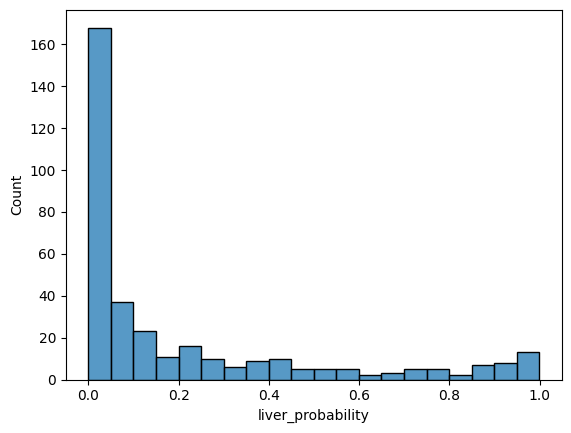

In [81]:
sns.histplot(
    data=hero_data,
    x="liver_probability",
    #hue="sofa_liver_day1",
    palette="Set1", 
    #kde=True,
    multiple="stack", 
    bins=20
)

In [82]:
from joblib import dump


with open("models/liver_protein_model.pkl", "wb") as f:

    dump(lr_clf, f)

with open("models/liver_protein_scaler.pkl", "wb") as f:

    dump(protein_scaler, f)
